In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("/content/Middle-East_aggregated_data_up_to-2026-03-07_(1).xlsx")

In [ ]:
# 모든 값이 비어있는(NaN) 행만 제거
df_cleaned = df.dropna(how='all').reset_index(drop=True)

# 결과 확인
print(f"제거 전 행 개수: {len(df)}")
print(f"제거 후 행 개수: {len(df_cleaned)}")

# 정제된 데이터를 새 파일로 저장
df_cleaned.to_csv('Middle-East_cleaned_data.csv', index=False)

제거 전 행 개수: 144526
제거 후 행 개수: 96056


In [ ]:
df = pd.read_csv("/content/Middle-East_cleaned_data.csv")

#1. 데이터 탐색

In [ ]:
print(df.shape)
print("\n")
print(df.head())
print("\n")
df.dtypes

(96056, 13)


         WEEK       REGION  COUNTRY    ADMIN1                  EVENT_TYPE  \
0  2026-03-07  Middle East  Bahrain   Capital  Explosions/Remote violence   
1  2026-03-07  Middle East  Bahrain   Capital      Strategic developments   
2  2026-03-07  Middle East  Bahrain   Capital      Strategic developments   
3  2026-03-07  Middle East  Bahrain  Muharraq  Explosions/Remote violence   
4  2026-03-07  Middle East  Bahrain  Northern                       Riots   

          SUB_EVENT_TYPE  EVENTS  FATALITIES  POPULATION_EXPOSURE  \
0       Air/drone strike     7.0         1.0                  NaN   
1                Arrests     2.0         0.0                  NaN   
2  Disrupted weapons use     8.0         0.0                  NaN   
3       Air/drone strike     3.0         0.0                  NaN   
4  Violent demonstration     1.0         0.0                  NaN   

            DISORDER_TYPE     ID  CENTROID_LATITUDE  CENTROID_LONGITUDE  
0      Political violence  285.0  

,0
WEEK,object
REGION,object
COUNTRY,object
ADMIN1,object
EVENT_TYPE,object
SUB_EVENT_TYPE,object
EVENTS,float64
FATALITIES,float64
POPULATION_EXPOSURE,float64
DISORDER_TYPE,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96056 entries, 0 to 96055
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   WEEK                 96056 non-null  object 
 1   REGION               96056 non-null  object 
 2   COUNTRY              96056 non-null  object 
 3   ADMIN1               96056 non-null  object 
 4   EVENT_TYPE           96056 non-null  object 
 5   SUB_EVENT_TYPE       96055 non-null  object 
 6   EVENTS               96056 non-null  float64
 7   FATALITIES           96056 non-null  float64
 8   POPULATION_EXPOSURE  73057 non-null  float64
 9   DISORDER_TYPE        96056 non-null  object 
 10  ID                   96046 non-null  float64
 11  CENTROID_LATITUDE    96056 non-null  float64
 12  CENTROID_LONGITUDE   96056 non-null  float64
dtypes: float64(6), object(7)
memory usage: 9.5+ MB


# 2. 데이터 전처리

결측치 파악

In [ ]:
print("결측치 개수")
print(df.isnull().sum())
print("\n")
print("결측치 비율")
print((df.isnull().mean()*100).round(1))

결측치 개수
WEEK                       0
REGION                     0
COUNTRY                    0
ADMIN1                     0
EVENT_TYPE                 0
SUB_EVENT_TYPE             1
EVENTS                     0
FATALITIES                 0
POPULATION_EXPOSURE    22999
DISORDER_TYPE              0
ID                        10
CENTROID_LATITUDE          0
CENTROID_LONGITUDE         0
dtype: int64


결측치 비율
WEEK                    0.0
REGION                  0.0
COUNTRY                 0.0
ADMIN1                  0.0
EVENT_TYPE              0.0
SUB_EVENT_TYPE          0.0
EVENTS                  0.0
FATALITIES              0.0
POPULATION_EXPOSURE    23.9
DISORDER_TYPE           0.0
ID                      0.0
CENTROID_LATITUDE       0.0
CENTROID_LONGITUDE      0.0
dtype: float64


POPULATION_EXPOSURE의 빈 행 체크

In [ ]:
missing_pop_rows = df[df['POPULATION_EXPOSURE'].isnull()]
print(f"비어있는 행 총 개수: {len(missing_pop_rows)}")

비어있는 행 총 개수: 22999


-> I열의 비어있는 행에 대해 회귀분석 예정. 회귀분석을 통해 null값 없어짐.

결측치 처리
1. ID : 없앨 행이니 상관x
2. SUB_EVENT_TYPE : 고민 필요

In [ ]:
print(df[df['SUB_EVENT_TYPE'].isnull()])

         WEEK       REGION COUNTRY   ADMIN1                  EVENT_TYPE  \
8  2026-03-07  Middle East    Iran  Bushehr  Explosions/Remote violence   

  SUB_EVENT_TYPE  EVENTS  FATALITIES  POPULATION_EXPOSURE       DISORDER_TYPE  \
8            NaN     2.0         0.0                  NaN  Political violence   

       ID  CENTROID_LATITUDE  CENTROID_LONGITUDE  
8  1331.0            28.7846             51.5038  


# 3. 그룹별 추이 파악

그룹의 구분 : Iran / OPEC / Other

In [ ]:
# 고유 국가 리스트 추출 및 정렬
countries = df['COUNTRY'].unique()
countries.sort()

# 결과 출력
print("--- 데이터셋에 포함된 전체 국가 리스트 ---")
print(countries)

--- 데이터셋에 포함된 전체 국가 리스트 ---
['Bahrain' 'Iran' 'Iraq' 'Israel' 'Jordan' 'Kuwait' 'Lebanon' 'Oman'
 'Palestine' 'Qatar' 'Saudi Arabia' 'Syria' 'Turkey'
 'United Arab Emirates' 'Yemen']


OPEC 회원국 : 알제리, 적도기니, 가봉, 이란, 이라크, 쿠웨이트, 리비아, 나이지리아, 콩고 공화국, 사우디아라비아, 아랍에미리트, 베네수엘라

Group 1 : Iran

Group 2 : Iraq, Kuwait, Saudi Arabia, United Arab Emirates

Group 3 :Bahrain, Israel, Jordan, Lebanon, Oman, Palestine, Qatar, Syria, Turkey, Yemen

In [ ]:
# 그룹 정의
opec_members = ['Iraq', 'Kuwait', 'Saudi Arabia', 'United Arab Emirates']

def classify_group(country):
    if country == 'Iran':
        return 'Iran'
    elif country in opec_members:
        return 'OPEC'
    else:
        return 'Other'

# 새로운 GROUP 컬럼 생성
df['GROUP_3'] = df['COUNTRY'].apply(classify_group)

# 그룹별 데이터 개수 확인
print(df['GROUP_3'].value_counts())

GROUP_3
Other    72831
OPEC     19439
Iran      3786
Name: count, dtype: int64


In [ ]:
# 그룹별 규모 파악 (전체 사건 수, 사망자 수, 평균 인구 노출)
group_profile = df.groupby('GROUP_3').agg({
    'EVENTS': 'sum',
    'FATALITIES': 'sum',
    'POPULATION_EXPOSURE': 'mean' # I열의 그룹별 평균 수준
}).reset_index()

# 그룹별 주요 사건 유형(EVENT_TYPE) 분포 확인
# 각 그룹에서 어떤 종류의 분쟁이 주로 발생하는지 파악
event_dist = df.groupby(['GROUP_3', 'EVENT_TYPE']).size().unstack(fill_value=0)

print("--- [1] 그룹별 전체 규모 ---")
print(group_profile)
print("\n--- [2] 그룹별 사건 유형 분포 (어떤 사건이 주를 이루는가) ---")
print(event_dist)

# 사망자 발생 강도 (사건 1건당 평균 사망자 수)
group_profile['FATALITY_RATE'] = group_profile['FATALITIES'] / group_profile['EVENTS']
print("\n--- [3] 그룹별 사건당 평균 사망자 수 (분쟁 강도) ---")
print(group_profile[['GROUP_3', 'FATALITY_RATE']])

--- [1] 그룹별 전체 규모 ---
  GROUP_3    EVENTS  FATALITIES  POPULATION_EXPOSURE
0    Iran    7018.0     32811.0        116658.948987
1    OPEC   60232.0    114142.0        161904.765995
2   Other  361529.0    400375.0         76877.062372

--- [2] 그룹별 사건 유형 분포 (어떤 사건이 주를 이루는가) ---
EVENT_TYPE  Battles  Explosions/Remote violence  Protests  Riots  \
GROUP_3                                                            
Iran            408                         253       764    782   
OPEC           4173                        7490       347    772   
Other         15522                       23802      3429   5818   

EVENT_TYPE  Strategic developments  Violence against civilians  
GROUP_3                                                         
Iran                           978                         601  
OPEC                          4592                        2065  
Other                        15700                        8560  

--- [3] 그룹별 사건당 평균 사망자 수 (분쟁 강도) ---
  GROUP_3  FATALITY

Group별 최다 빈도 SUB_EVENT_TYPE

In [ ]:
group_order_3 = ['Iran', 'OPEC', 'Other']

# 세부 사건 유형(SUB_EVENT_TYPE) 누적 분석
if 'SUB_EVENT_TYPE' in df.columns:
    df_sub = df.dropna(subset=['SUB_EVENT_TYPE'])

    results_3 = []

    for g_name in group_order_3:
        # 해당 그룹 데이터 필터링
        g_data = df_sub[df_sub['GROUP_3'] == g_name]
        total_in_group = len(g_data)

        if total_in_group == 0: continue

        # 빈도 및 누적 계산
        counts = g_data['SUB_EVENT_TYPE'].value_counts()
        cumulative_counts = counts.cumsum()
        cumulative_percents = (cumulative_counts / total_in_group) * 100

        # 상위 10개 추출 및 결과 저장
        top_10 = counts.head(10)
        for sub_type, count in top_10.items():
            percentage = (count / total_in_group) * 100
            results_3.append({
                'Group': g_name,
                'Sub-Event Type': sub_type,
                'Count': count,
                'Percentage (%)': round(percentage, 2),
                'Cum. Percentage (%)': round(cumulative_percents[sub_type], 2)
            })

    summary_table_3 = pd.DataFrame(results_3)

    # 결과 출력
    print("--- [분석] 3개 그룹별 세부 사건 유형(SUB_EVENT_TYPE) 누적 비중 ---")
    for g in group_order_3:
        print(f"\n[{g} 그룹 상세 내역]")
        subset = summary_table_3[summary_table_3['Group'] == g]
        # 표 형식으로 출력
        print(subset[['Sub-Event Type', 'Count', 'Percentage (%)', 'Cum. Percentage (%)']].to_string(index=False))
        print("-" * 70)
else:
    print("데이터에 'SUB_EVENT_TYPE' 컬럼이 존재하지 않습니다.")

--- [분석] 3개 그룹별 세부 사건 유형(SUB_EVENT_TYPE) 누적 비중 ---

[Iran 그룹 상세 내역]
                    Sub-Event Type  Count  Percentage (%)  Cum. Percentage (%)
         Protest with intervention    634           16.75                16.75
             Violent demonstration    603           15.93                32.68
                            Attack    601           15.88                48.56
                             Other    563           14.87                63.43
                       Armed clash    408           10.78                74.21
                           Arrests    211            5.57                79.79
                      Mob violence    179            4.73                84.52
                  Air/drone strike    142            3.75                88.27
Excessive force against protesters    130            3.43                91.70
             Disrupted weapons use    103            2.72                94.43
---------------------------------------------------------------

인사이트


1. 인구노출도 평균[회귀 전] : OPEC(161904.765995) > Iran(116658.948987)
2.  사망률 : 이란(4.67)로, OPEC(1.89)이나 Other(1.10) 그룹에 비해 압도적으로 높음
3. 이란 : Attack보다 Protest with intervention, Violent demonstration가 높음. 전쟁보다 내부 소요와 그에 따른 국가 권력의 강경 대응에 집중함.
4.   OPEC : 직접적 타격 공격의 누적 비율이 66.21%





In [ ]:
# OPEC 국가들만 필터링
df_opec = df[df['COUNTRY'].isin(opec_members)]

# OPEC 국가별 인구 노출도(POPULATION_EXPOSURE) 평균 계산
opec_exposure_mean = df_opec.groupby('COUNTRY')['POPULATION_EXPOSURE'].mean().sort_values(ascending=False)

print("--- OPEC 국가별 인구 노출도(I열) 평균 ---")
print(opec_exposure_mean)

--- OPEC 국가별 인구 노출도(I열) 평균 ---
COUNTRY
Iraq                    171629.192759
United Arab Emirates    117016.846154
Saudi Arabia             51748.887842
Kuwait                   31289.750000
Name: POPULATION_EXPOSURE, dtype: float64


이란보다 이라크의 수치가 더 큼

## 시각화

### 1) 그룹별 전체 규모 (Total Events and Fatalities)

  : 각 그룹에서 발생한 전체 사건 수(Events)와 총 사망자 수(Fatalities)를 막대그래프로 비교


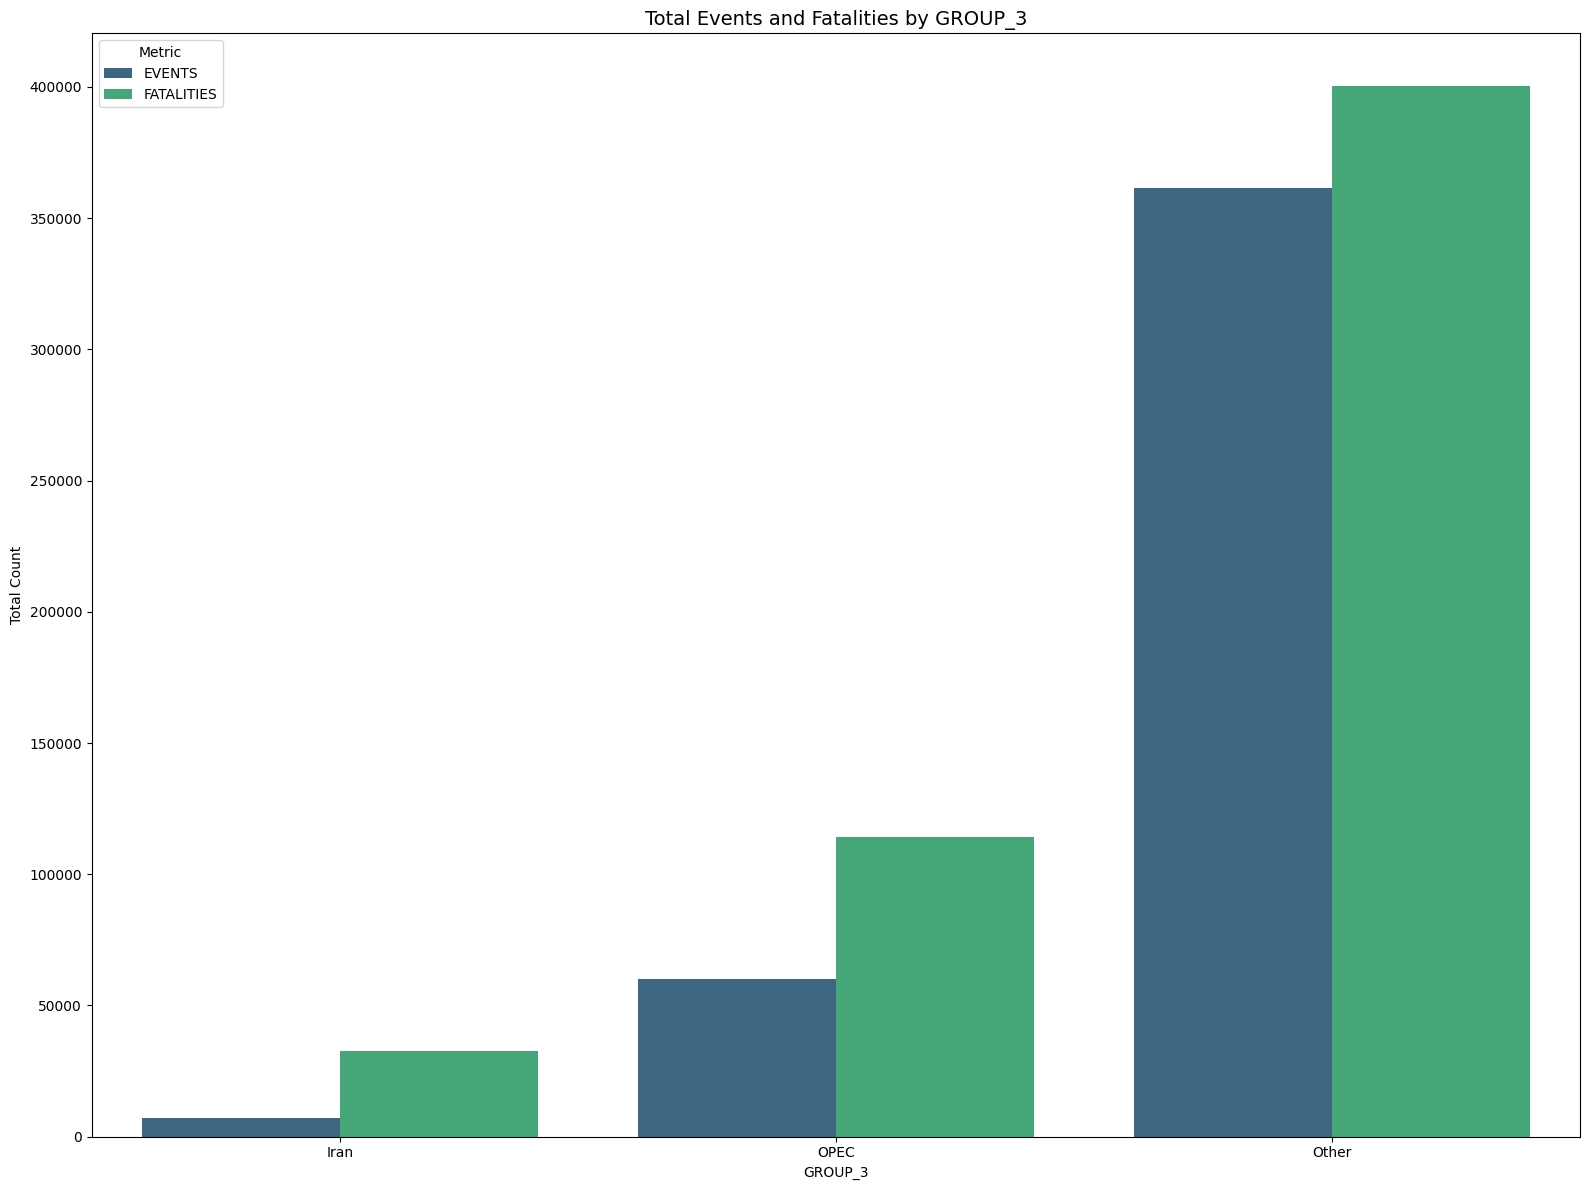

In [ ]:
# 통계 데이터 준비
group_profile = df.groupby('GROUP_3').agg({
    'EVENTS': 'sum',
    'FATALITIES': 'sum',
    'POPULATION_EXPOSURE': 'mean'
}).reset_index()

group_profile['FATALITY_RATE'] = group_profile['FATALITIES'] / group_profile['EVENTS']

# 사건 유형 비중 계산
event_dist = df.groupby(['GROUP_3', 'EVENT_TYPE']).size().unstack(fill_value=0)
event_dist_pct = event_dist.div(event_dist.sum(axis=1), axis=0) * 100

# 시각화
fig, ax = plt.subplots(figsize=(16, 12))

# 전체 규모: 사건 수 및 사망자 수
scale_df = group_profile.melt(id_vars='GROUP_3', value_vars=['EVENTS', 'FATALITIES'], var_name='Metric')
sns.barplot(ax=ax, x='GROUP_3', y='value', hue='Metric', data=scale_df, palette='viridis')
ax.set_title('Total Events and Fatalities by GROUP_3', fontsize=14)
ax.set_ylabel('Total Count')

plt.tight_layout()

### 2) 사망률

: 사건당 평균 사망자 수 (Conflict Intensity)

/tmp/ipykernel_253/2165440835.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax, x='GROUP_3', y='FATALITY_RATE',


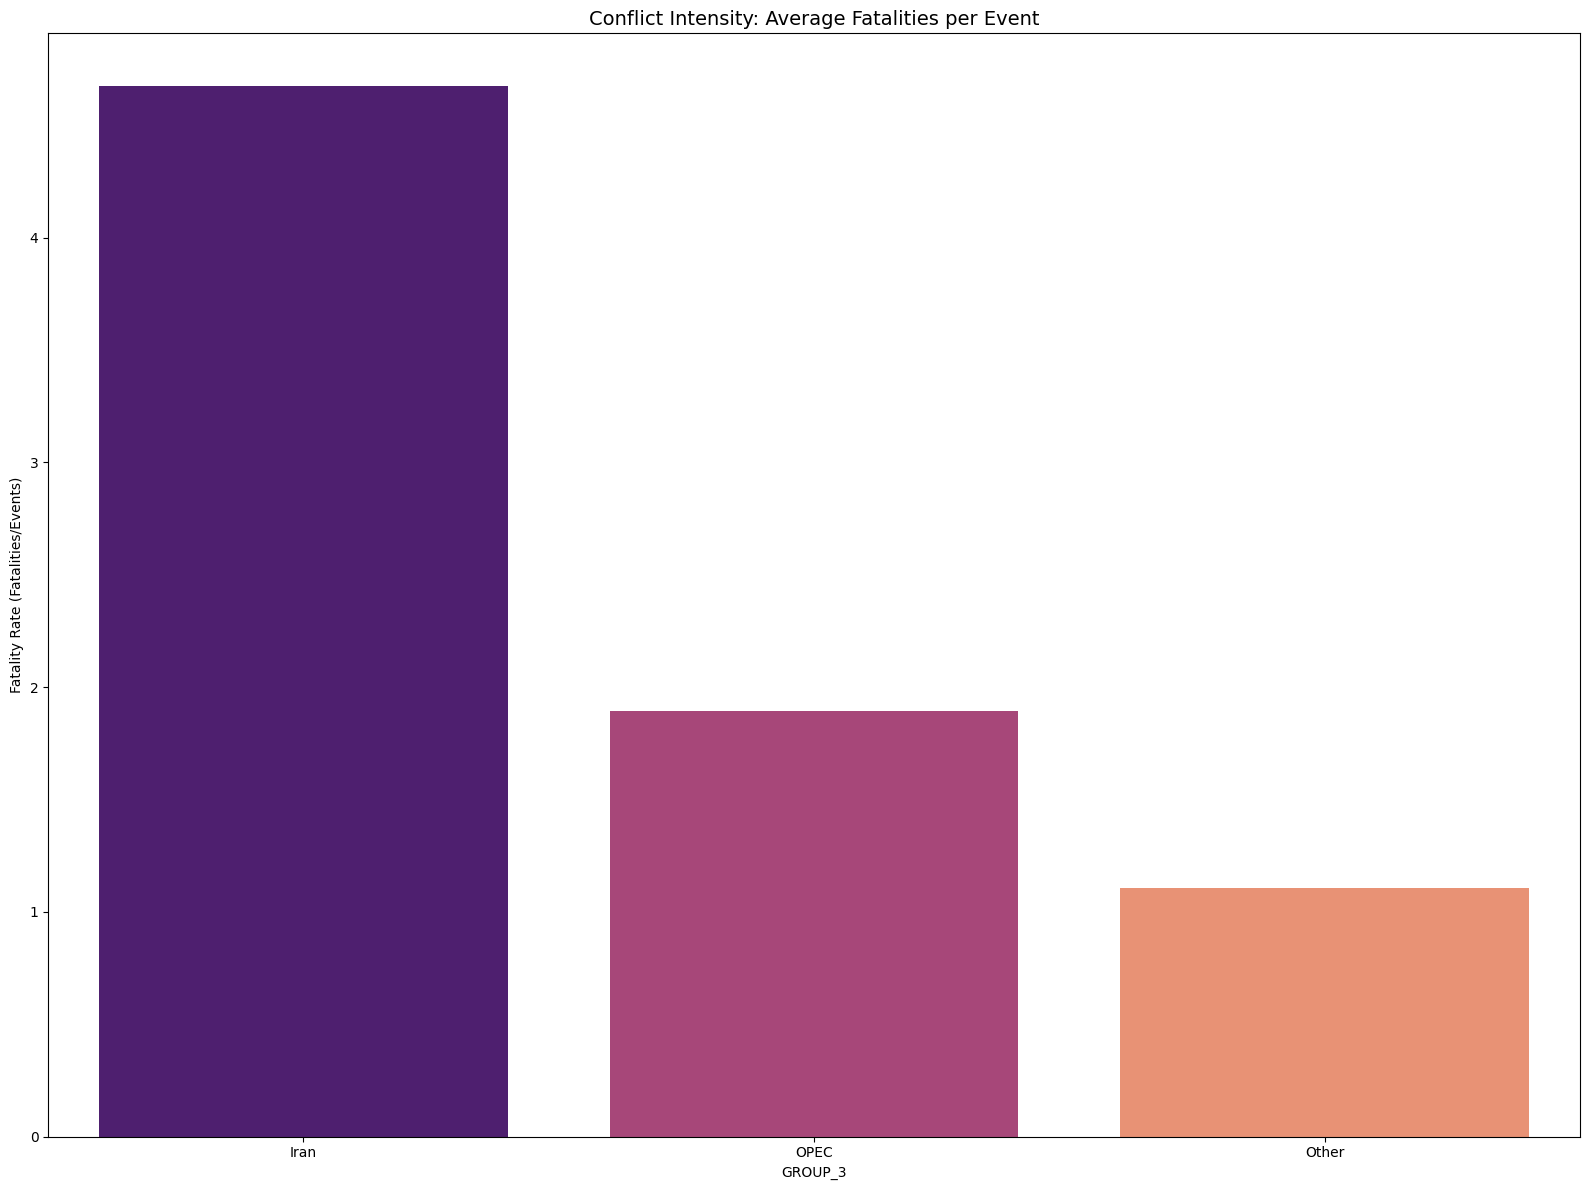

In [ ]:
# 시각화
fig, ax = plt.subplots(figsize=(16, 12))

# 분쟁 강도: 사건당 평균 사망자 수 (정렬 적용)
sns.barplot(ax=ax, x='GROUP_3', y='FATALITY_RATE',
            data=group_profile.sort_values('FATALITY_RATE', ascending=False), palette='magma')
ax.set_title('Conflict Intensity: Average Fatalities per Event', fontsize=14)
ax.set_ylabel('Fatality Rate (Fatalities/Events)')

plt.tight_layout()

### 3) 분쟁의 성격

: 사건 유형 구성비 (Event Type Distribution %)

-> 사건 유형에 따라 각 국가별 대응 전략 등 마련 가능

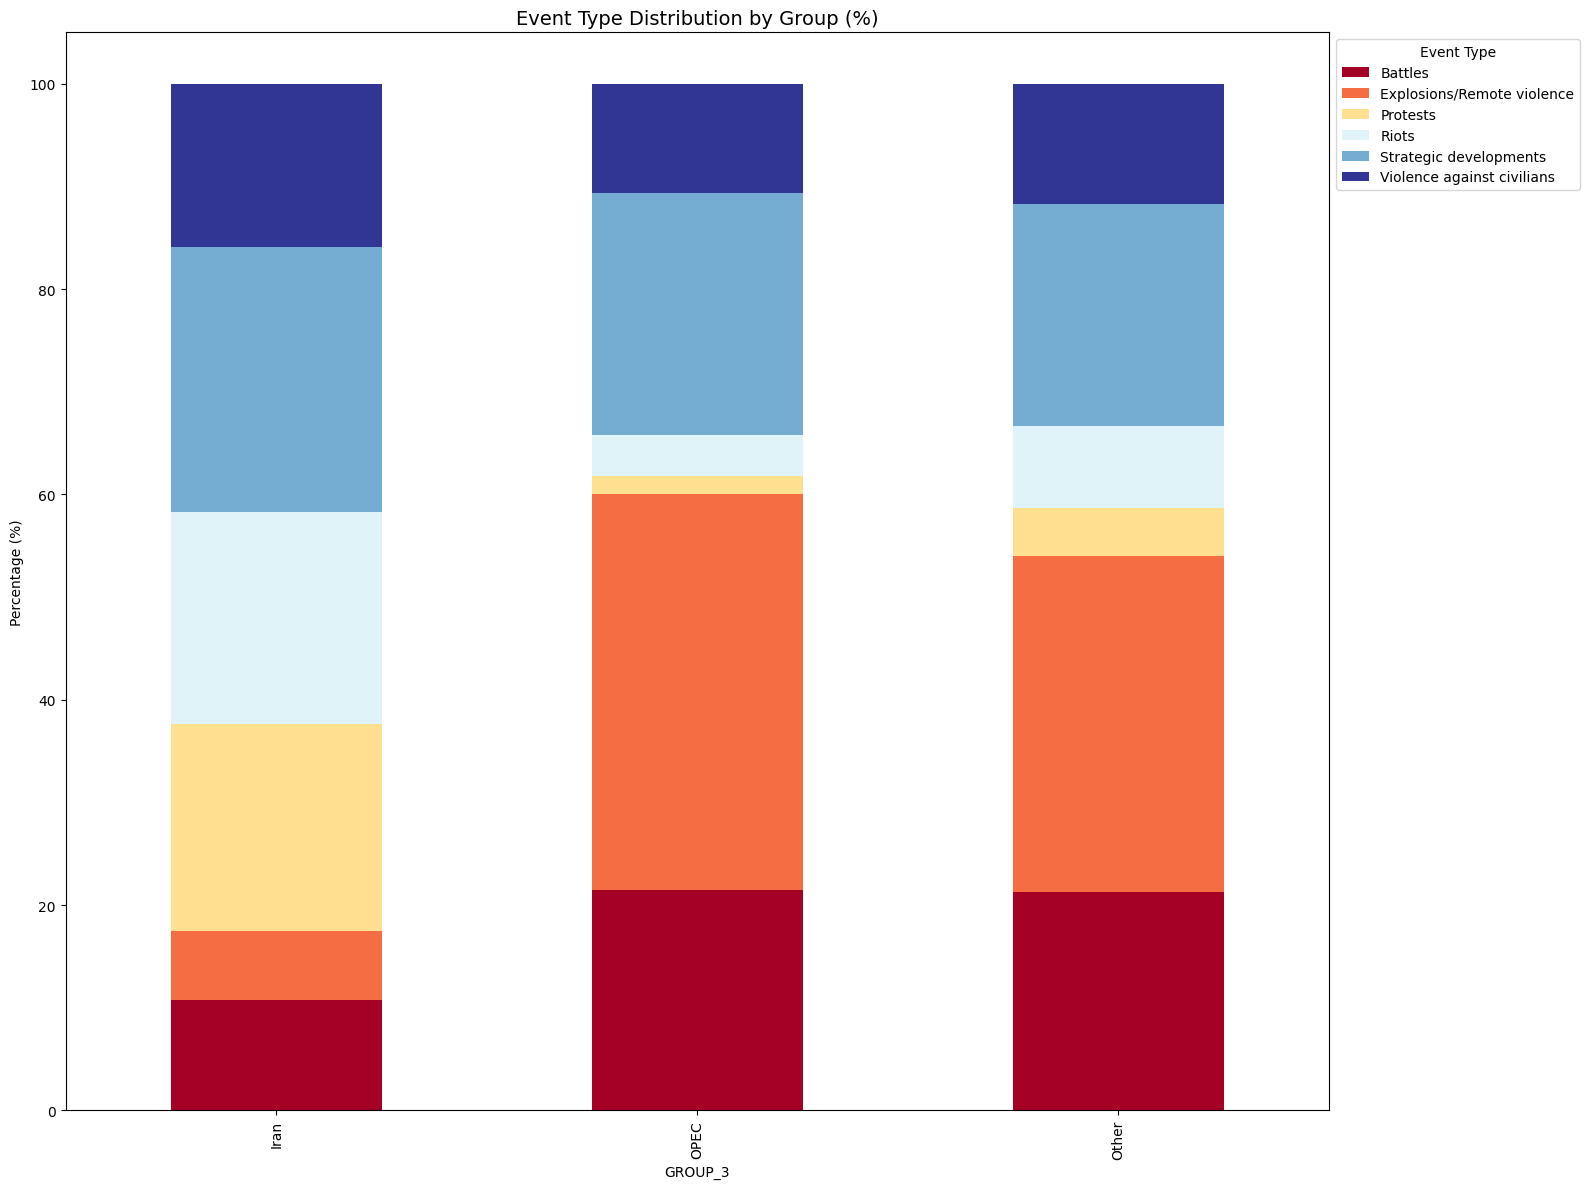

In [ ]:
# 시각화
fig, ax = plt.subplots(figsize=(16, 12))

# 분쟁 성격: 사건 유형 구성비 (%)
event_dist_pct.plot(kind='bar', stacked=True, ax=ax, colormap='RdYlBu')
ax.set_title('Event Type Distribution by Group (%)', fontsize=14)
ax.set_ylabel('Percentage (%)')
ax.legend(title='Event Type', bbox_to_anchor=(1, 1), loc='upper left')

plt.tight_layout()

### 4) 평균 인구 노출도

: 사건이 발생한 지점 주변의 평균 인구 노출 규모

/tmp/ipykernel_253/874877484.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax, x='GROUP_3', y='POPULATION_EXPOSURE',


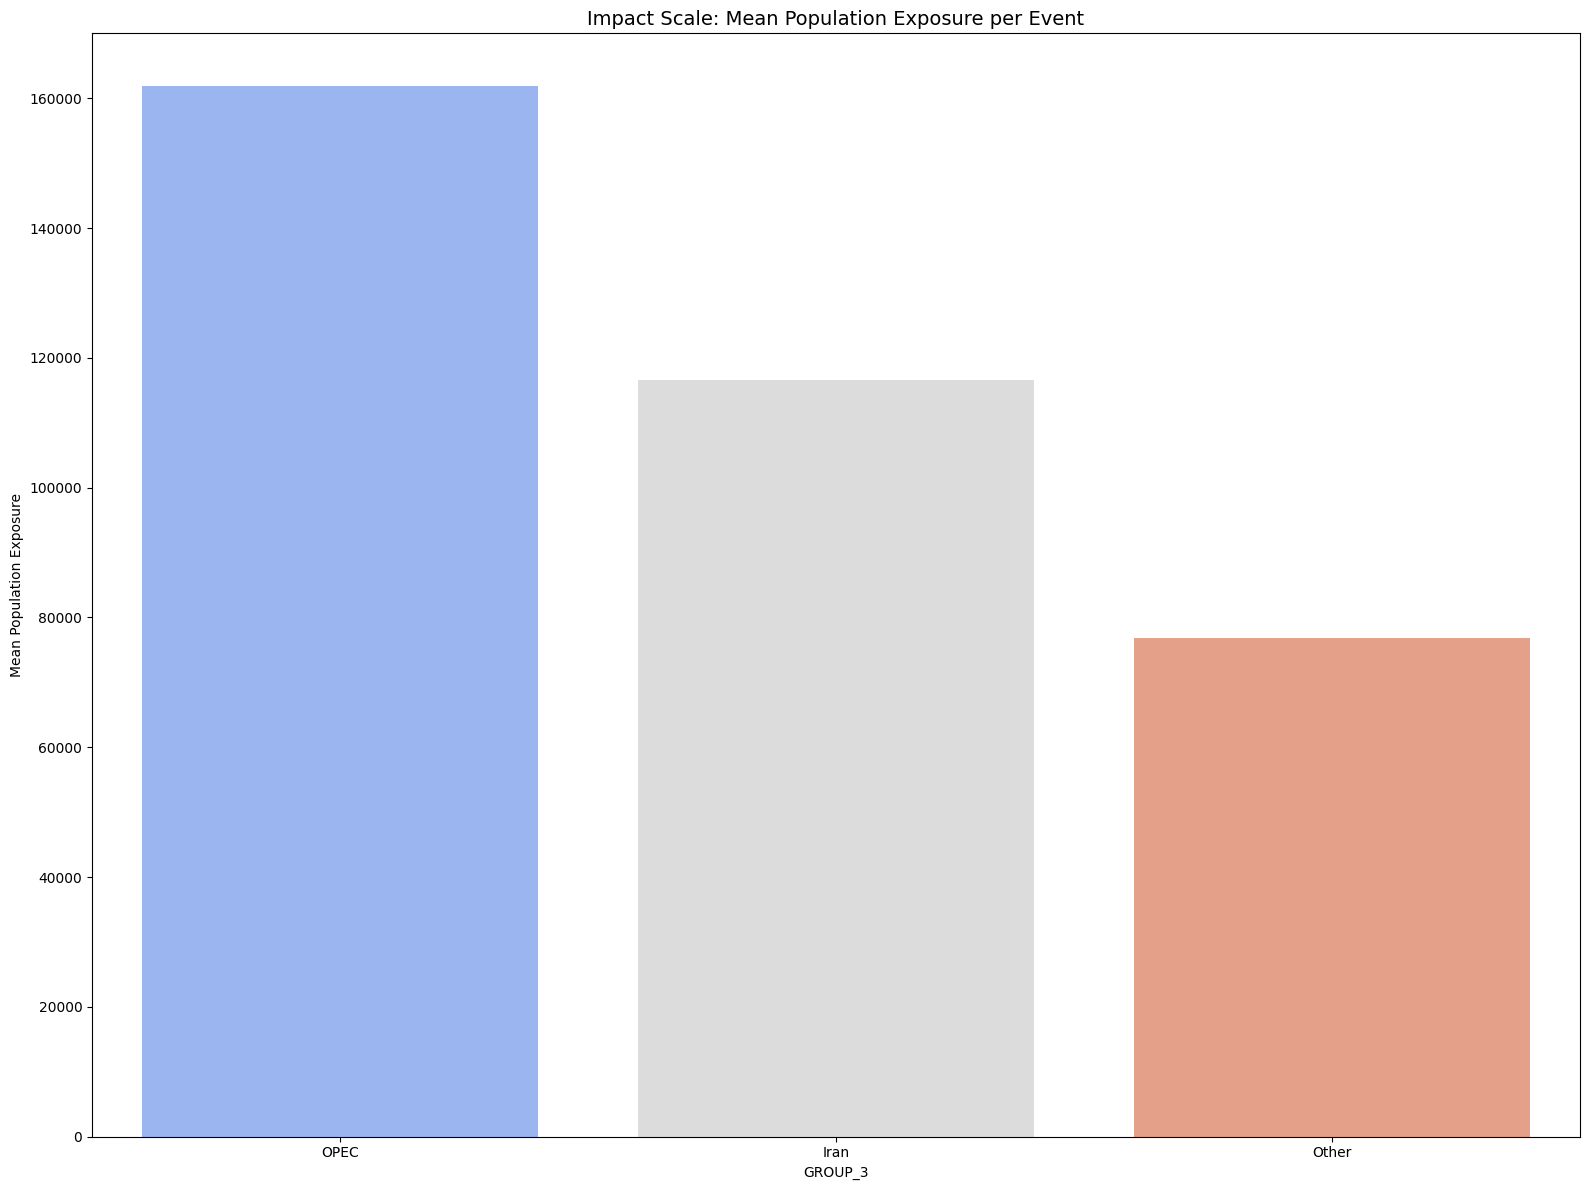

In [ ]:
# 시각화
fig, ax = plt.subplots(figsize=(16, 12))

# 영향 규모: 사건당 평균 인구 노출도 (정렬 적용)
sns.barplot(ax=ax, x='GROUP_3', y='POPULATION_EXPOSURE',
            data=group_profile.sort_values('POPULATION_EXPOSURE', ascending=False), palette='coolwarm')
ax.set_title('Impact Scale: Mean Population Exposure per Event', fontsize=14)
ax.set_ylabel('Mean Population Exposure')

plt.tight_layout()

## 그룹의 구분
: 이란 / opec O & 호르무즈 인근 / opec X & 호르무즈 인근 / 그 외

Group 1 :Iran

Group 2 :Iraq, Kuwait, Saudi Arabia, United Arab Emirates

Group 3 :Bahrain, Qatar, Oman

Group 4 :Israel, Jordan, Lebanon, Palestine, Syria, Turkey, Yemen

In [ ]:
# 상세 그룹 분류 함수
opec_members = ['Iraq', 'Kuwait', 'Saudi Arabia', 'United Arab Emirates']
hormuz_near = ['Iraq', 'Kuwait', 'Saudi Arabia', 'United Arab Emirates', 'Oman', 'Qatar', 'Bahrain']

def classify_detailed(country):
    if country == 'Iran':
        return 'Iran'
    elif country in opec_members and country in hormuz_near:
        return 'OPEC_Hormuz'
    elif country not in opec_members and country in hormuz_near:
        return 'Non_OPEC_Hormuz'
    else:
        return 'Other'

df['GROUP_4'] = df['COUNTRY'].apply(classify_detailed)

In [ ]:
# 출력 순서 정의 (사용자 지정 순서)
group_order = ['Iran', 'OPEC_Hormuz', 'Non_OPEC_Hormuz', 'Other']

# 카테고리 형식을 사용하여 순서 고정
group_profile['GROUP_4'] = pd.Categorical(group_profile['GROUP_4'], categories=group_order, ordered=True)
group_profile = group_profile.sort_values('GROUP_4')

# 그룹별 규모 파악 (전체 사건 수, 사망자 수, 평균 인구 노출)
group_profile = df.groupby('GROUP_4').agg({
    'EVENTS': 'sum',
    'FATALITIES': 'sum',
    'POPULATION_EXPOSURE': 'mean' # I열의 그룹별 평균 수준
}).reset_index()

# 그룹별 주요 사건 유형(EVENT_TYPE) 분포 확인
event_dist = df.groupby(['GROUP_4', 'EVENT_TYPE']).size().unstack(fill_value=0)

# 사망자 발생 강도 (사건 1건당 평균 사망자 수)
group_profile['FATALITY_RATE'] = group_profile['FATALITIES'] / group_profile['EVENTS']

# 결과 출력
print("--- [1] 그룹별 전체 규모 (세분화 분류) ---")
print(group_profile)

print("\n--- [2] 그룹별 사건 유형 분포 (사건 성격) ---")
print(event_dist)

print("\n--- [3] 그룹별 사건당 평균 사망자 수 (분쟁 강도) ---")
print(group_profile[['GROUP_4', 'FATALITY_RATE']])


--- [1] 그룹별 전체 규모 (세분화 분류) ---
           GROUP_4    EVENTS  FATALITIES  POPULATION_EXPOSURE  FATALITY_RATE
0             Iran    7018.0     32811.0        116658.948987       4.675264
1  Non_OPEC_Hormuz    5029.0        51.0         46755.652003       0.010141
2      OPEC_Hormuz   60232.0    114142.0        161904.765995       1.895039
3            Other  356500.0    400324.0         77580.980926       1.122928

--- [2] 그룹별 사건 유형 분포 (사건 성격) ---
EVENT_TYPE       Battles  Explosions/Remote violence  Protests  Riots  \
GROUP_4                                                                 
Iran                 408                         253       764    782   
Non_OPEC_Hormuz        8                          43       237    974   
OPEC_Hormuz         4173                        7490       347    772   
Other              15514                       23759      3192   4844   

EVENT_TYPE       Strategic developments  Violence against civilians  
GROUP_4                                  

Group별 최다 빈도 SUB_EVENT_TYPE

In [ ]:
# 세부 사건 유형(SUB_EVENT_TYPE) 분석 데이터 생성
if 'SUB_EVENT_TYPE' in df.columns:
    # 결측치 제외
    df_sub = df.dropna(subset=['SUB_EVENT_TYPE'])

    results = []

    for g_name in group_order:
        # 해당 그룹 데이터 필터링
        g_data = df_sub[df_sub['GROUP_4'] == g_name]
        total_events_in_group = len(g_data)

        if total_events_in_group == 0: continue # 데이터가 없는 그룹 건너뛰기

        # 빈도 계산 (한 번만 수행)
        counts = g_data['SUB_EVENT_TYPE'].value_counts()

        # 누적 합계 및 누적 비율 계산 (total_g 대신 total_events_in_group 사용)
        cumulative_counts = counts.cumsum()
        cumulative_percents = (cumulative_counts / total_events_in_group) * 100

        # 상위 10개 추출 및 결과 수집
        top_10_sub = counts.head(10)

        for sub_type, count in top_10_sub.items():
            percentage = (count / total_events_in_group) * 100
            results.append({
                'Group': g_name,
                'Sub-Event Type': sub_type,
                'Count': count,
                'Percentage (%)': round(percentage, 2),
                'Cum. Percentage (%)': round(cumulative_percents[sub_type], 2) # 누적 비율 추가
            })

    # 데이터프레임으로 변환
    summary_table = pd.DataFrame(results)

    print("--- [최종 분석] 4개 그룹별 세부 사건 유형(SUB_EVENT_TYPE) TOP 10 ---")
    for g in group_order:
        print(f"\n[{g} 그룹 상세 내역]")
        # 출력 컬럼에 누적 비율(Cum. Percentage (%)) 추가
        subset = summary_table[summary_table['Group'] == g]
        print(subset[['Sub-Event Type', 'Count', 'Percentage (%)', 'Cum. Percentage (%)']].to_string(index=False))
        print("-" * 65)
else:
    print("데이터에 'SUB_EVENT_TYPE' 컬럼이 존재하지 않습니다.")

--- [최종 분석] 4개 그룹별 세부 사건 유형(SUB_EVENT_TYPE) TOP 10 ---

[Iran 그룹 상세 내역]
                    Sub-Event Type  Count  Percentage (%)  Cum. Percentage (%)
         Protest with intervention    634           16.75                16.75
             Violent demonstration    603           15.93                32.68
                            Attack    601           15.88                48.56
                             Other    563           14.87                63.43
                       Armed clash    408           10.78                74.21
                           Arrests    211            5.57                79.79
                      Mob violence    179            4.73                84.52
                  Air/drone strike    142            3.75                88.27
Excessive force against protesters    130            3.43                91.70
             Disrupted weapons use    103            2.72                94.43
-----------------------------------------------------------

인사이트



1.   사망률 : 이란(4.67)로, OPEC(1.89)이나 Other(1.10) 그룹에 비해 압도적으로 높음
2.   인구노출도 평균[회귀 전] : OPEC_Hormuz(161904.765995) > Non_OPEC_Hormuz(46755.652003)

  cf) 그룹 3 인구노출도 평균[회귀 전] : OPEC(161904.765995) > Iran(116658.948987)

  => 3개 그룹으로 분류해도 되지 않을까라는 생각

3. OPEC_Hormuz 그룹 : 물리적 타격이 있는 공격의 영향 큼. 그룹 3개로 나눴을 때 높았던 이유가 OPEC_Hormuz 그룹의 직접적 공격이 컸기 때문.






## 시각화

In [ ]:
# 통계 데이터 요약
stats = df.groupby('GROUP_4').agg({
    'EVENTS': 'sum',
    'FATALITIES': 'sum',
    'POPULATION_EXPOSURE': 'mean'
}).reindex(group_order).reset_index()
stats['FATALITY_RATE'] = stats['FATALITIES'] / stats['EVENTS']

# 사건 유형 비중 계산
event_dist = df.groupby(['GROUP_4', 'EVENT_TYPE']).size().unstack(fill_value=0).reindex(group_order)
event_dist_pct = event_dist.div(event_dist.sum(axis=1), axis=0) * 100

### 1) 그룹별 전체 규모 (Total Events and Fatalities)

  : 각 그룹에서 발생한 전체 사건 수(Events)와 총 사망자 수(Fatalities)를 막대그래프로 비교

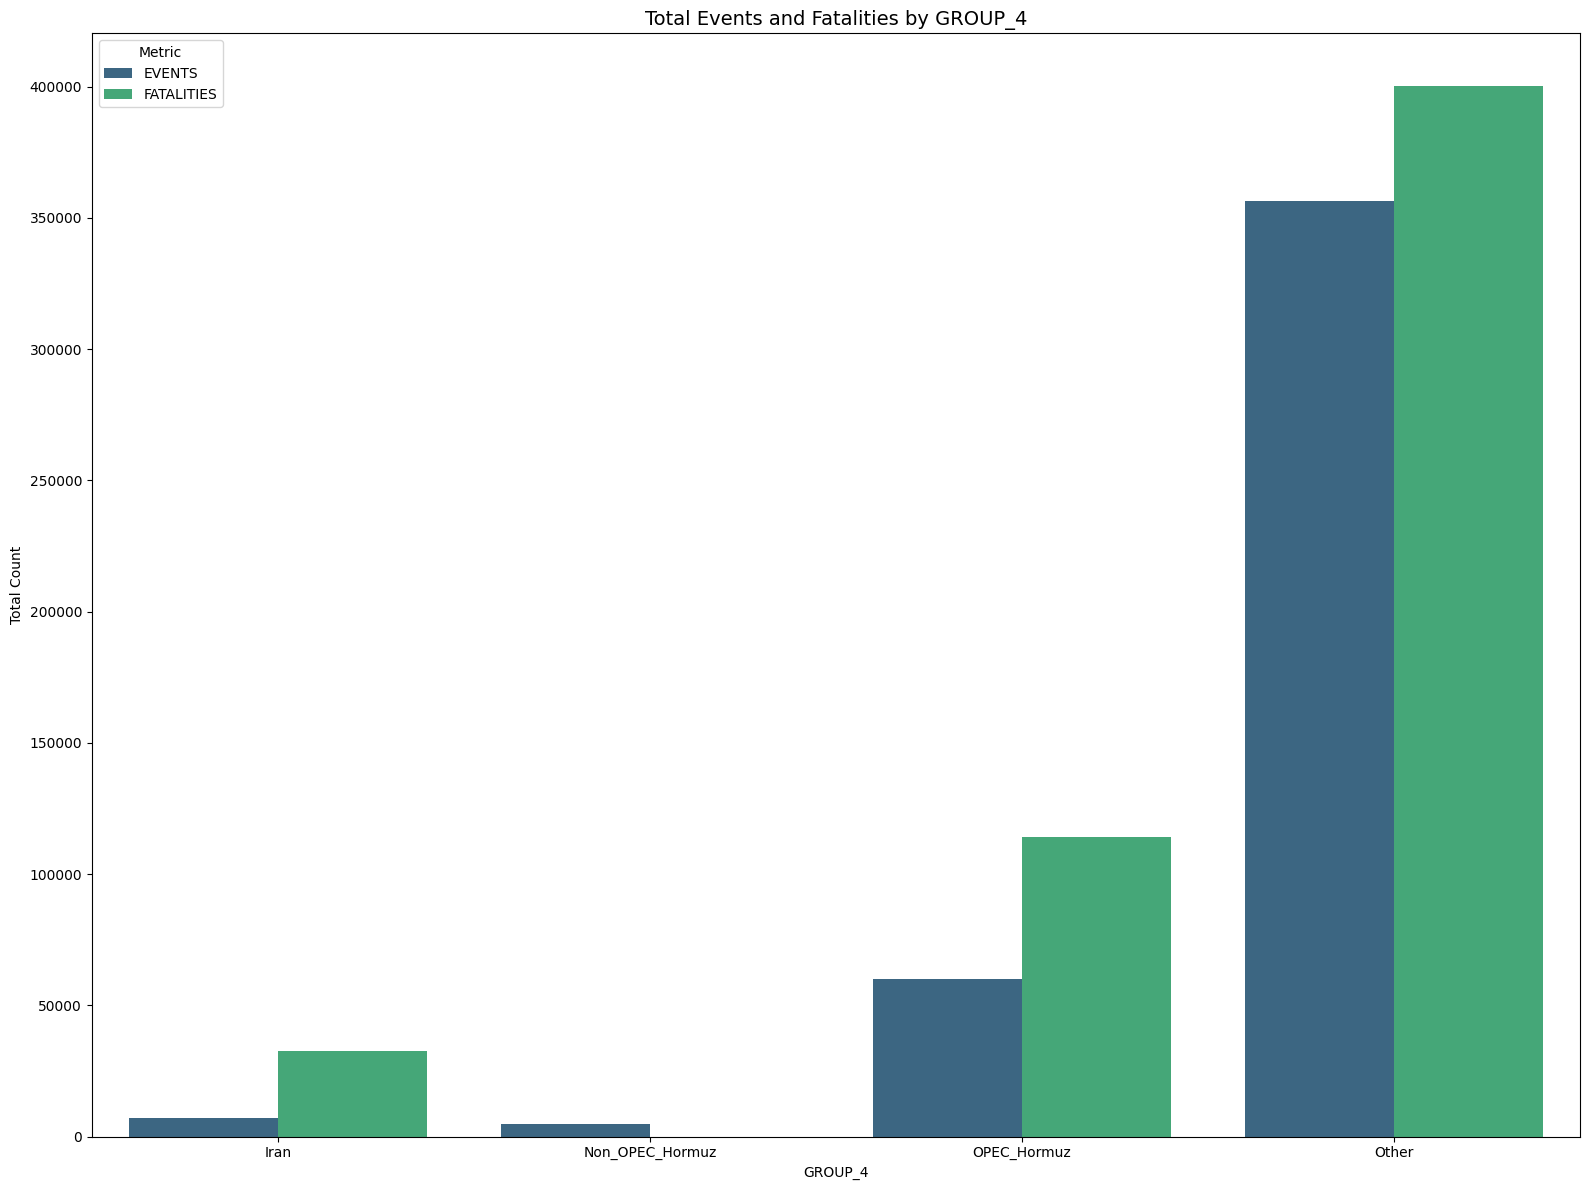

In [ ]:
# 시각화
fig, ax = plt.subplots(figsize=(16, 12))

# 전체 규모: 사건 수 및 사망자 수
scale_df = group_profile.melt(id_vars='GROUP_4', value_vars=['EVENTS', 'FATALITIES'], var_name='Metric')
sns.barplot(ax=ax, x='GROUP_4', y='value', hue='Metric', data=scale_df, palette='viridis')
ax.set_title('Total Events and Fatalities by GROUP_4', fontsize=14)
ax.set_ylabel('Total Count')

plt.tight_layout()

### 2) 사망률

: 사건당 평균 사망자 수 (Conflict Intensity)

/tmp/ipykernel_253/1015429576.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax, x='GROUP_4', y='FATALITY_RATE',


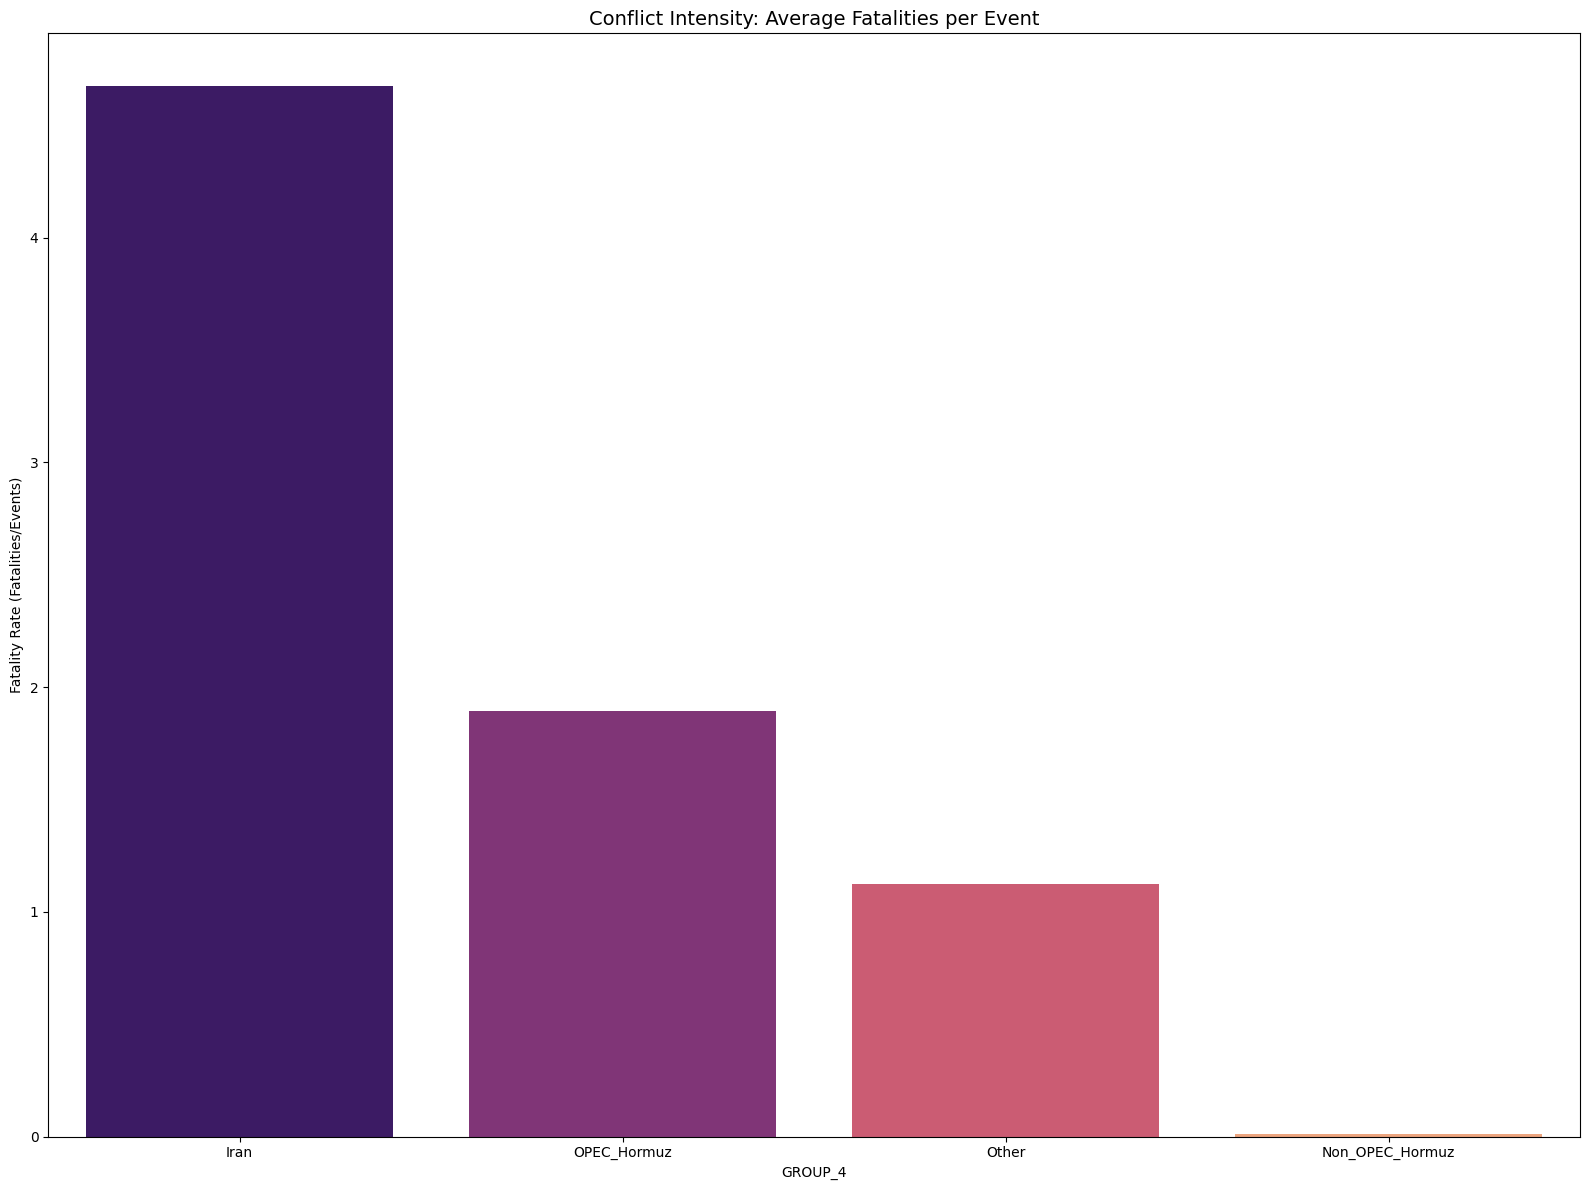

In [ ]:
# 시각화
fig, ax = plt.subplots(figsize=(16, 12))

# 분쟁 강도: 사건당 평균 사망자 수 (정렬 적용)
sns.barplot(ax=ax, x='GROUP_4', y='FATALITY_RATE',
            data=group_profile.sort_values('FATALITY_RATE', ascending=False), palette='magma')
ax.set_title('Conflict Intensity: Average Fatalities per Event', fontsize=14)
ax.set_ylabel('Fatality Rate (Fatalities/Events)')

plt.tight_layout()

### 3) 분쟁의 성격

: 사건 유형 구성비 (Event Type Distribution %)

-> 사건 유형에 따라 각 국가별 대응 전략 등 마련 가능

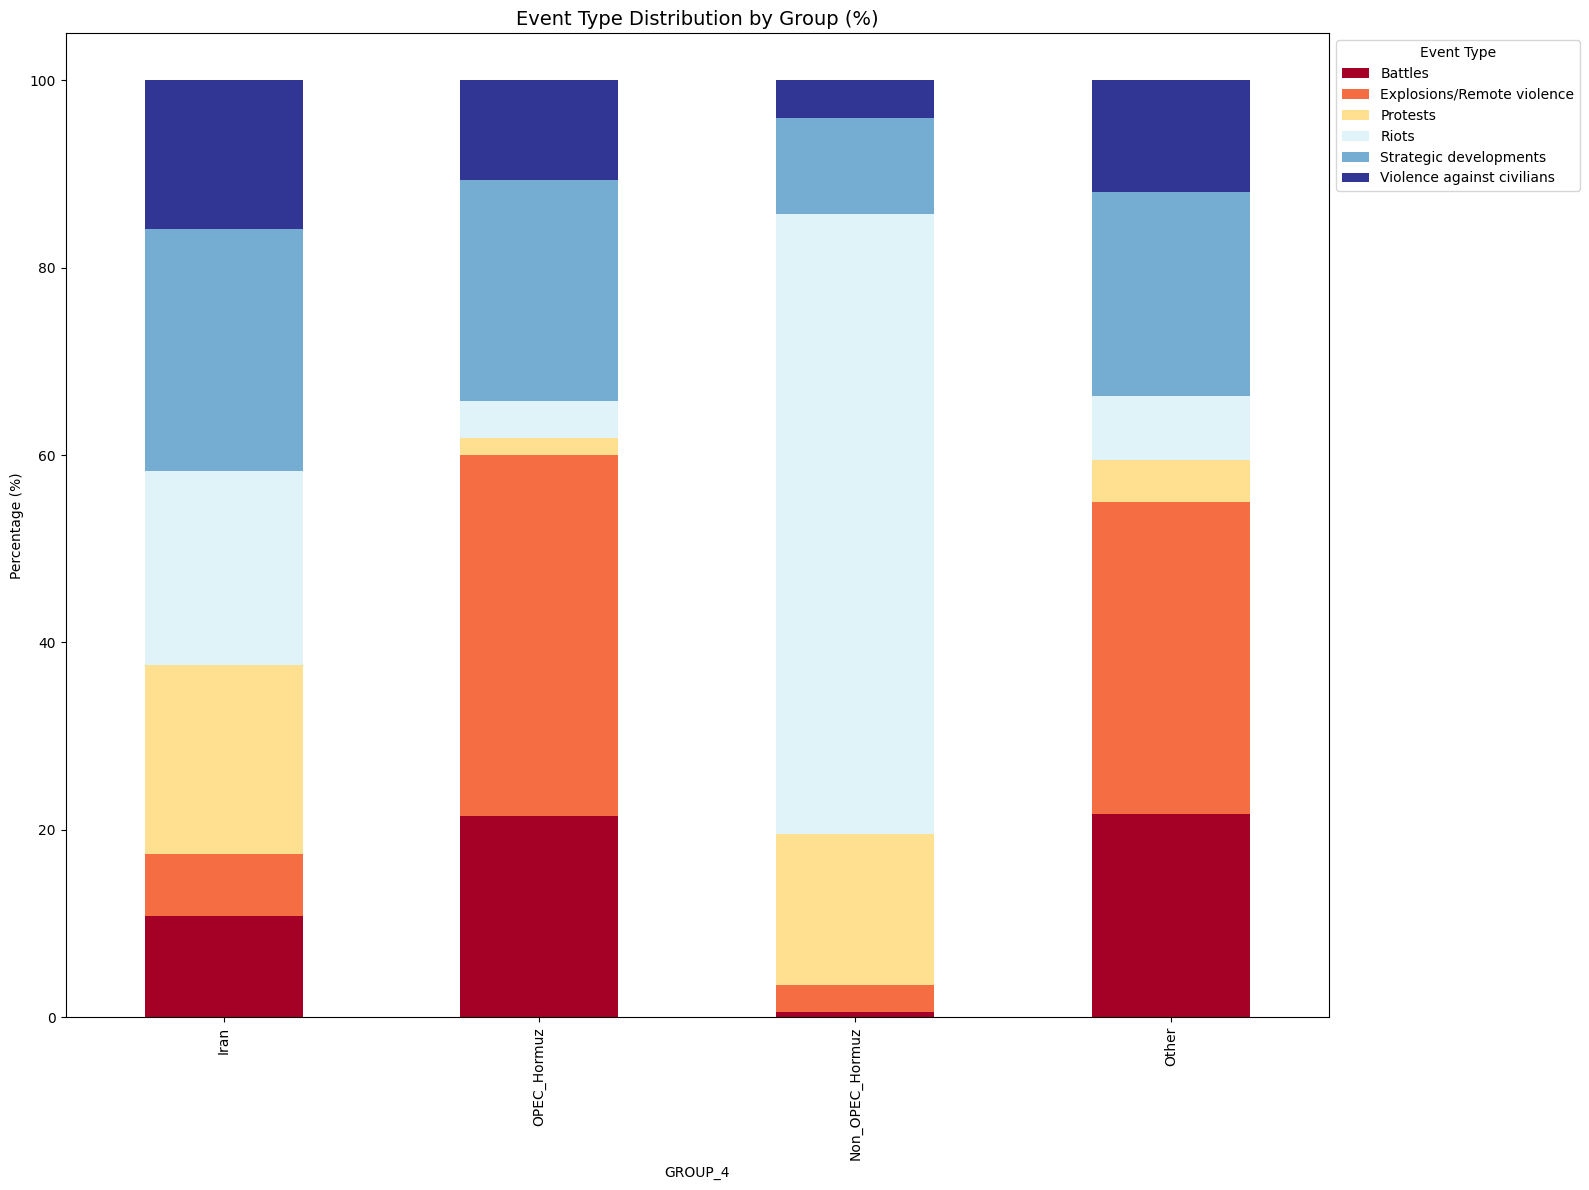

In [ ]:
# 시각화
fig, ax = plt.subplots(figsize=(16, 12))

# 분쟁 성격: 사건 유형 구성비 (%)
event_dist_pct.plot(kind='bar', stacked=True, ax=ax, colormap='RdYlBu')
ax.set_title('Event Type Distribution by Group (%)', fontsize=14)
ax.set_ylabel('Percentage (%)')
ax.legend(title='Event Type', bbox_to_anchor=(1, 1), loc='upper left')

plt.tight_layout()

### 4) 평균 인구 노출도

: 사건이 발생한 지점 주변의 평균 인구 노출 규모

/tmp/ipykernel_253/1839240773.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax, x='GROUP_4', y='POPULATION_EXPOSURE',


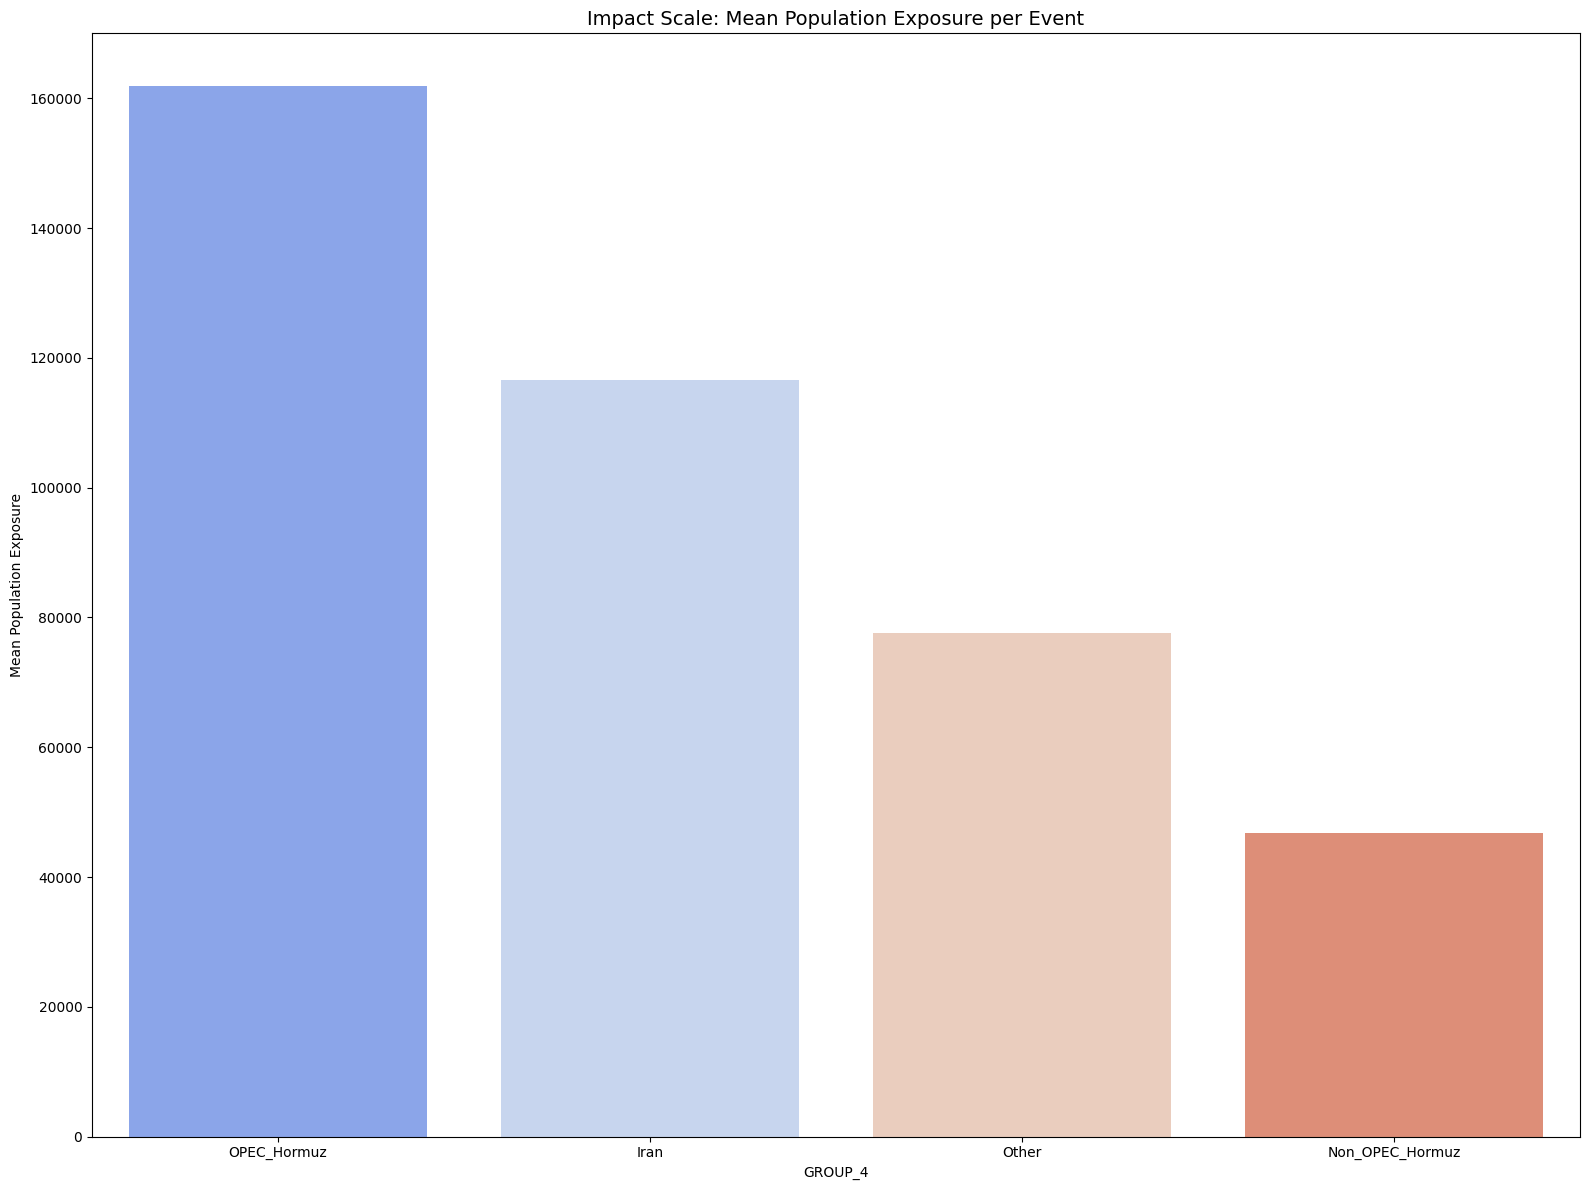

In [ ]:
# 시각화
fig, ax = plt.subplots(figsize=(16, 12))

# 영향 규모: 사건당 평균 인구 노출도 (정렬 적용)
sns.barplot(ax=ax, x='GROUP_4', y='POPULATION_EXPOSURE',
            data=group_profile.sort_values('POPULATION_EXPOSURE', ascending=False), palette='coolwarm')
ax.set_title('Impact Scale: Mean Population Exposure per Event', fontsize=14)
ax.set_ylabel('Mean Population Exposure')

plt.tight_layout()

# 4. 상관관계

### 1) 그룹 내 지표 간 상관관계
: 사건 수(EVENTS), 사망자 수(FATALITIES), 인구 노출도(I열)

3개 그룹에 대해 수행

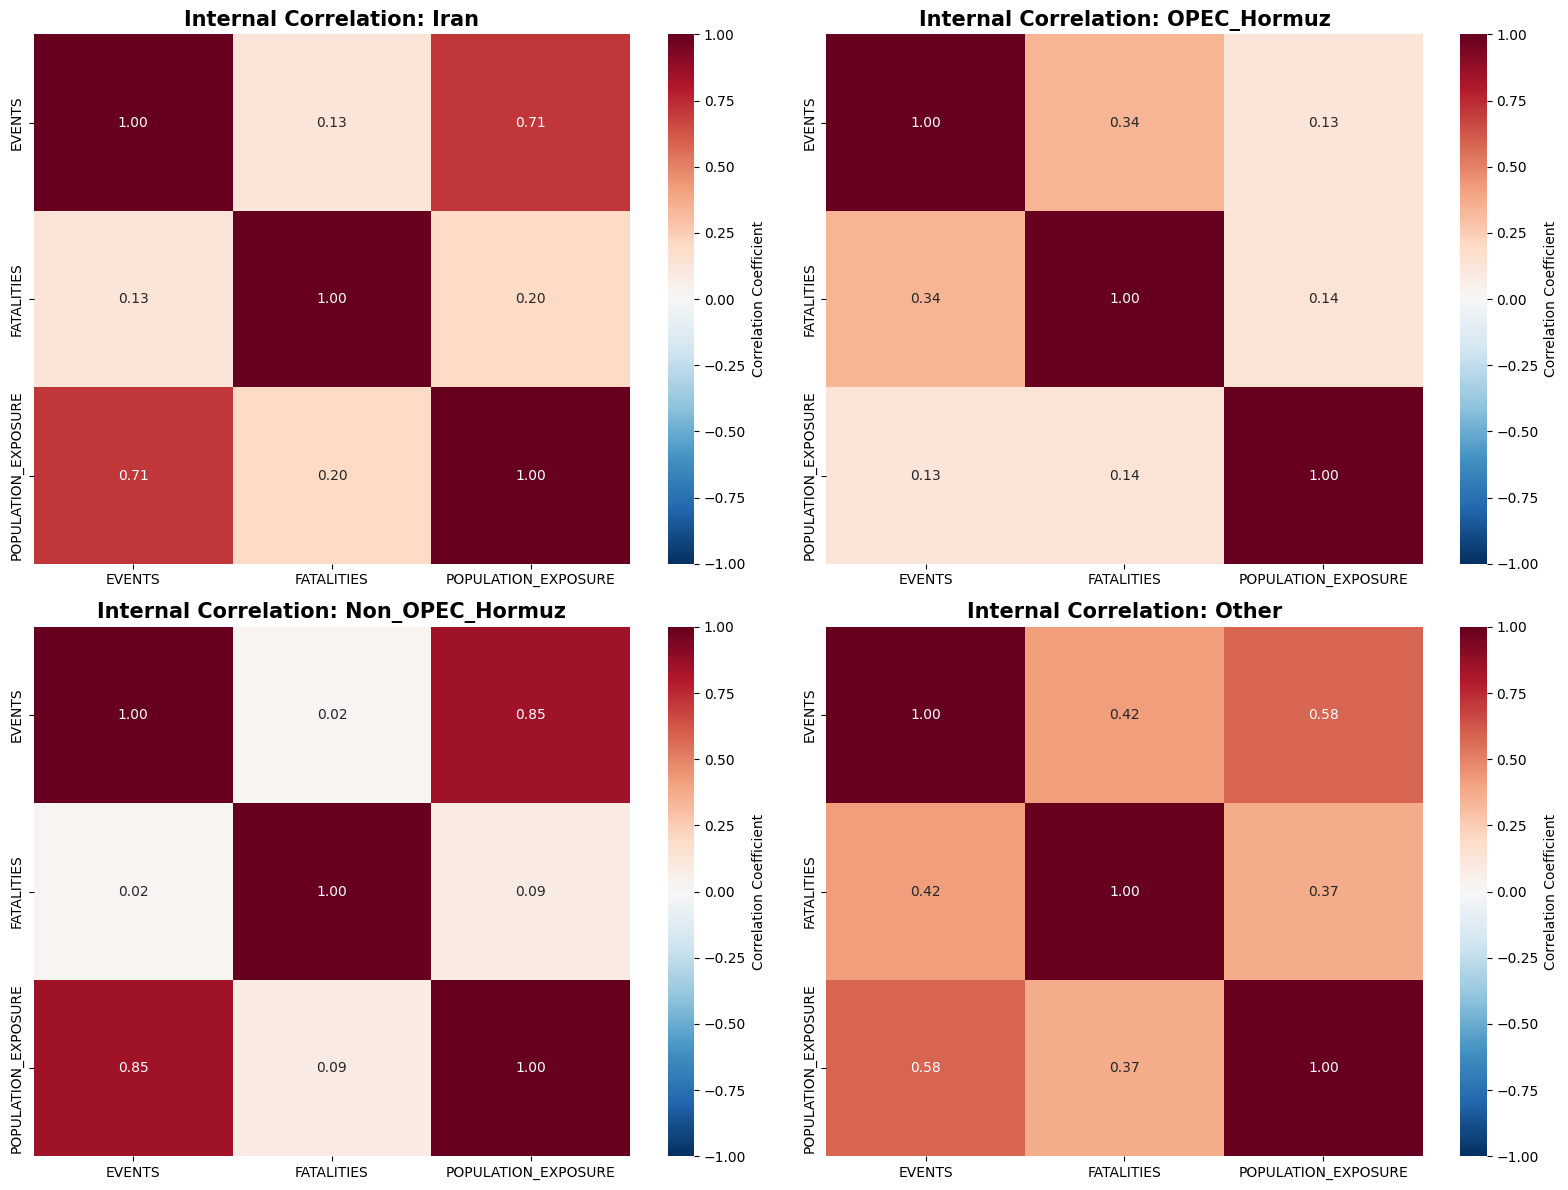

--- [4개 그룹별 지표 간 상관계수 상세] ---

>> Iran Group Correlation Matrix:
                     EVENTS  FATALITIES  POPULATION_EXPOSURE
EVENTS                1.000       0.131                0.712
FATALITIES            0.131       1.000                0.201
POPULATION_EXPOSURE   0.712       0.201                1.000
----------------------------------------

>> OPEC_Hormuz Group Correlation Matrix:
                     EVENTS  FATALITIES  POPULATION_EXPOSURE
EVENTS                1.000       0.338                0.131
FATALITIES            0.338       1.000                0.139
POPULATION_EXPOSURE   0.131       0.139                1.000
----------------------------------------

>> Non_OPEC_Hormuz Group Correlation Matrix:
                     EVENTS  FATALITIES  POPULATION_EXPOSURE
EVENTS                1.000       0.019                0.846
FATALITIES            0.019       1.000                0.085
POPULATION_EXPOSURE   0.846       0.085                1.000
---------------------------------

In [ ]:
# 상관관계 시각화 (2x2 그리드)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, g_name in enumerate(group_order):
    # 분석 대상 지표 선택: 사건 수(EVENTS), 사망자 수(FATALITIES), 인구 노출도(I열)
    group_data = df[df['GROUP_4'] == g_name][['EVENTS', 'FATALITIES', 'POPULATION_EXPOSURE']]

    # 피어슨 상관계수 계산
    corr_matrix = group_data.corr()

    # 히트맵 그리기
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r',
                ax=axes[i], vmin=-1, vmax=1, center=0, cbar_kws={'label': 'Correlation Coefficient'})

    axes[i].set_title(f'Internal Correlation: {g_name}', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('group_4_internal_correlation.png')
plt.show()

# 수치 요약 데이터 출력
print("--- [4개 그룹별 지표 간 상관계수 상세] ---")
for g_name in group_order:
    group_data = df[df['GROUP_4'] == g_name][['EVENTS', 'FATALITIES', 'POPULATION_EXPOSURE']]
    print(f"\n>> {g_name} Group Correlation Matrix:")
    print(group_data.corr().round(3))
    print("-" * 40)

인사이트

1.   0.846[Non_OPEC_Hormuz] : 사건 수(EVENTS)와 인구 노출도(POPULATION_EXPOSURE)가 매우 높은 양의 상관관계

-> Violent demonstration, Protest 비율이 앞도적으로 높아서 그럴지도

2.   0.712[Iran] :  사건 수(EVENTS)와 인구 노출도(POPULATION_EXPOSURE)가 매우 높은 양의 상관관계

-> Protest, Violent demonstration 비율이 1,2위여서

3.   0.131[OPEC_Hormuz] : 사건 수(EVENTS)와 인구 노출도(POPULATION_EXPOSURE)가 별로 상관관계 없음

-> 그럼 어떤 곳을 타겟으로 공격?



### 2) 전이 효과 분석


(1) Other 그룹(시리아, 예멘 등)의 사건 발생이 1~2주 뒤에 OPEC이나 이란의 사건 발생으로 이어지는지 파악

--- [전이 효과 분석] 시차 상관계수 결과 ---
Predictor    Other Non_OPEC_Hormuz       Other Non_OPEC_Hormuz
Target        Iran            Iran OPEC_Hormuz     OPEC_Hormuz
Lag (Weeks)                                                   
1            0.033           0.151       0.167           0.292
2           -0.007          -0.053       0.152           0.250
3            0.002          -0.046       0.137           0.261
4            0.003          -0.066       0.132           0.256


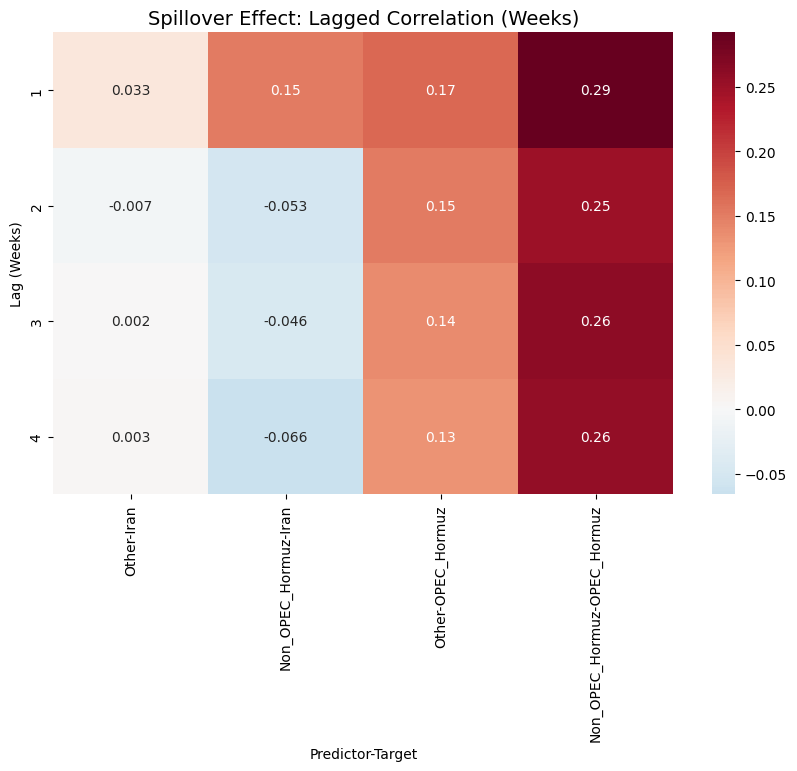

In [ ]:
#  주별 사건 수 시계열 데이터 생성
# 'WEEK'를 인덱스로, 'GROUP_4'를 컬럼으로 하여 사건 수 합계 계산
weekly_events = df.pivot_table(index='WEEK', columns='GROUP_4', values='EVENTS', aggfunc='sum').fillna(0)

# 시차(Lag) 데이터 생성 (최대 4주)
lags = [1, 2, 3, 4]
spillover_results = []

# 분석 타겟: Iran, OPEC_Hormuz
# 선행 지표: Other, Non_OPEC_Hormuz
targets = ['Iran', 'OPEC_Hormuz']
predictors = ['Other', 'Non_OPEC_Hormuz']

for target in targets:
    for predictor in predictors:
        for lag in lags:
            # 선행 지표를 lag만큼 뒤로 밀어서 현재의 타겟과 상관관계 계산
            correlation = weekly_events[target].corr(weekly_events[predictor].shift(lag))
            spillover_results.append({
                'Predictor': predictor,
                'Target': target,
                'Lag (Weeks)': lag,
                'Correlation': round(correlation, 3)
            })

# 결과 데이터프레임 변환 및 시각화
spillover_df = pd.DataFrame(spillover_results)
pivot_spillover = spillover_df.pivot(index='Lag (Weeks)', columns=['Predictor', 'Target'], values='Correlation')

print("--- [전이 효과 분석] 시차 상관계수 결과 ---")
print(pivot_spillover)

# 히트맵 시각화
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_spillover, annot=True, cmap='RdBu_r', center=0)
plt.title('Spillover Effect: Lagged Correlation (Weeks)', fontsize=14)
plt.savefig('spillover_effect_analysis.png')
plt.show()

(2) OPEC이나 이란의 사건 발생이 1~2주 뒤에 Other 그룹(시리아, 예멘 등)의 사건 발생으로 이어지는지 파악

--- [전이 효과 분석] 시차 상관계수 결과 ---
Predictor     Iran OPEC_Hormuz            Iran     OPEC_Hormuz
Target       Other       Other Non_OPEC_Hormuz Non_OPEC_Hormuz
Lag (Weeks)                                                   
1            0.070       0.190           0.010           0.257
2            0.033       0.179          -0.077           0.234
3            0.032       0.189          -0.080           0.233
4            0.023       0.190          -0.077           0.229


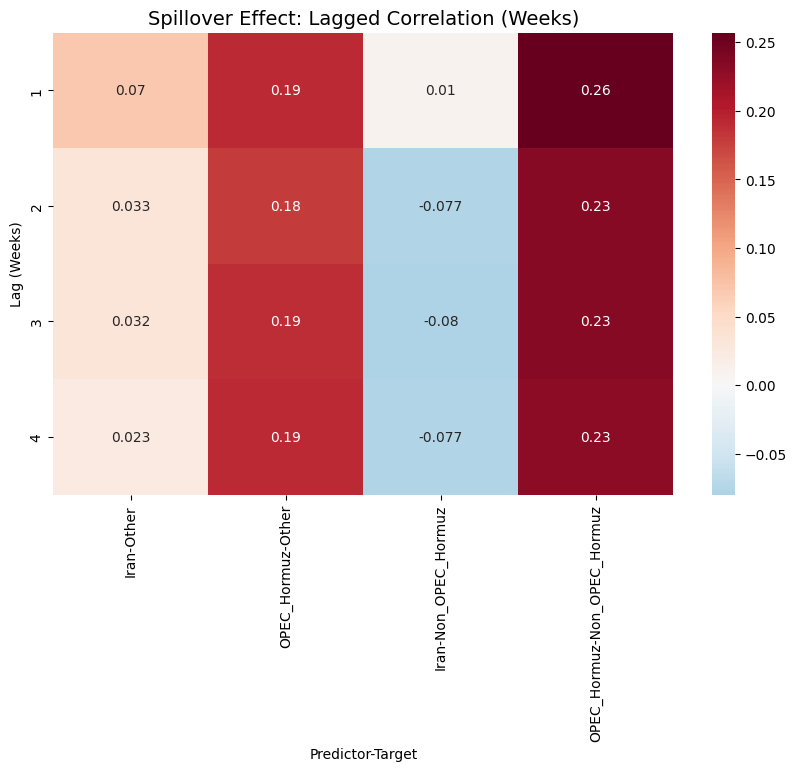

In [ ]:
#  주별 사건 수 시계열 데이터 생성
# 'WEEK'를 인덱스로, 'GROUP_4'를 컬럼으로 하여 사건 수 합계 계산
weekly_events = df.pivot_table(index='WEEK', columns='GROUP_4', values='EVENTS', aggfunc='sum').fillna(0)

# 시차(Lag) 데이터 생성 (최대 4주)
lags = [1, 2, 3, 4]
spillover_results = []

# 분석 타겟: Iran, OPEC_Hormuz
# 선행 지표: Other, Non_OPEC_Hormuz
predictors = ['Iran', 'OPEC_Hormuz']
targets = ['Other', 'Non_OPEC_Hormuz']

for target in targets:
    for predictor in predictors:
        for lag in lags:
            # 선행 지표를 lag만큼 뒤로 밀어서 현재의 타겟과 상관관계 계산
            correlation = weekly_events[target].corr(weekly_events[predictor].shift(lag))
            spillover_results.append({
                'Predictor': predictor,
                'Target': target,
                'Lag (Weeks)': lag,
                'Correlation': round(correlation, 3)
            })

# 결과 데이터프레임 변환 및 시각화
spillover_df = pd.DataFrame(spillover_results)
pivot_spillover = spillover_df.pivot(index='Lag (Weeks)', columns=['Predictor', 'Target'], values='Correlation')

print("--- [전이 효과 분석] 시차 상관계수 결과 ---")
print(pivot_spillover)

# 히트맵 시각화
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_spillover, annot=True, cmap='RdBu_r', center=0)
plt.title('Spillover Effect: Lagged Correlation (Weeks)', fontsize=14)
plt.savefig('spillover_effect_analysis.png')
plt.show()